1. Business Problem:
1.1. What is the business objective?
    1.1.1 Help bring audiences interested in cars to your website.
    1.1.2 Communicate with your target audience over social media to build a good market reputation.

'''

'''1.2. Are there any constraints?
    - Lack of a clear market or social media strategy may reduce business benefits.
    - Additional resources may be needed to manage your online presence.
    - Social media requires daily monitoring for effectiveness.
    - Exposure online can attract risks such as negative feedback, hacking, or inappropriate behavior.
'''

In [46]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, accuracy_score


In [52]:
# Load the dataset
file_path = "E:/Data Science/14-Naive Bayes/SalaryData_Test.csv"
salary_data = pd.read_csv(file_path)
salary_data

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15055,33,Private,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
15056,39,Private,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
15057,38,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
15058,44,Private,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [50]:
# Exploratory Data Analysis (EDA)
print("Dataset Columns:", salary_data.columns)
print("\nData Types:\n", salary_data.dtypes)
print("\nMissing Values:\n", salary_data.isna().sum())
print("\nDataset Description:\n", salary_data.describe())


Dataset Columns: Index(['age', 'workclass', 'education', 'educationno', 'maritalstatus',
       'occupation', 'relationship', 'race', 'sex', 'capitalgain',
       'capitalloss', 'hoursperweek', 'native', 'Salary'],
      dtype='object')

Data Types:
 age               int64
workclass        object
education        object
educationno       int64
maritalstatus    object
occupation       object
relationship     object
race             object
sex              object
capitalgain       int64
capitalloss       int64
hoursperweek      int64
native           object
Salary           object
dtype: object

Missing Values:
 age              0
workclass        0
education        0
educationno      0
maritalstatus    0
occupation       0
relationship     0
race             0
sex              0
capitalgain      0
capitalloss      0
hoursperweek     0
native           0
Salary           0
dtype: int64

Dataset Description:
                 age   educationno   capitalgain   capitalloss  hoursperweek
cou

In [56]:
# Encode categorical columns
label_encoder = LabelEncoder()
for column in ["workclass", "education", "maritalstatus", "occupation", "relationship", "race", "sex", "native", "Salary"]:
    if column in salary_data.columns:
        salary_data[column] = label_encoder.fit_transform(salary_data[column])


In [58]:
# Normalize numerical columns
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())


In [61]:
for column in ["age", "educationno", "capitalgain", "capitalloss", "hoursperweek"]:
    if column in salary_data.columns:
        salary_data[column] = normalize(salary_data[column])


In [63]:
# Define features and target
features = ["age", "educationno", "capitalgain", "capitalloss", "hoursperweek", "sex"]
target = "Salary"

In [65]:
# Split the dataset into training and testing sets
train_data, test_data = train_test_split(salary_data, test_size=0.2, random_state=42)
train_X = train_data[features]
train_y = train_data[target]
test_X = test_data[features]
test_y = test_data[target]


In [67]:
# Model Building and Evaluation
classifier = BernoulliNB()
classifier.fit(train_X, train_y)

BernoulliNB()

In [77]:
# Predict on the test dataset
test_predictions = classifier.predict(test_X)

In [71]:
# Evaluate the model
accuracy = accuracy_score(test_y, test_predictions)
print("\nTest Accuracy:", accuracy)



Test Accuracy: 0.7762284196547145


In [73]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_y, test_predictions)
print("\nConfusion Matrix:\n", conf_matrix)



Confusion Matrix:
 [[2136  110]
 [ 564  202]]


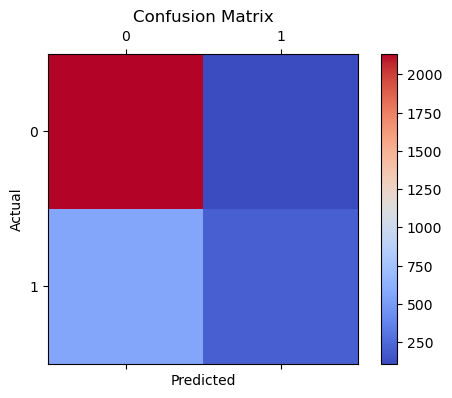

In [75]:
# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
plt.matshow(conf_matrix, cmap="coolwarm", fignum=1)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The solution helps the client improve marketing efficiency by targeting likely buyers,
increasing ROI, and enhancing customer segmentation. 
It drives informed decision-making, enabling sustainable growth and better customer satisfaction.